In [1]:
import sqlite3, pandas as pd, seaborn as sns, matplotlib.pyplot as plt

conn = sqlite3.connect('../sql/shop.db')
orders = pd.read_sql('SELECT * FROM orders', conn)
customers = pd.read_sql('SELECT * FROM customers', conn)
df = orders.merge(customers, left_on='customer_id', right_on='id', suffixes=('_order', '_cust'))
df.head()

,id_order,customer_id,amount,order_date,id_cust,name,city,signup_date
0,1,1,4444.896554,2026-06-26,1,Андрей,Токио,2024-04-24
1,2,4,7003.943488,2026-08-25,4,Артур,Лондон,2025-01-30
2,3,2,9758.661281,2025-03-07,2,Маша,Париж,2025-12-17
3,4,6,7882.036622,2026-06-17,6,Мухамед,Париж,2025-11-30
4,5,5,4558.820785,2025-03-31,5,Гоша,Москва,2024-04-12


Text(0.5, 1.0, 'Распределение сумм заказов')

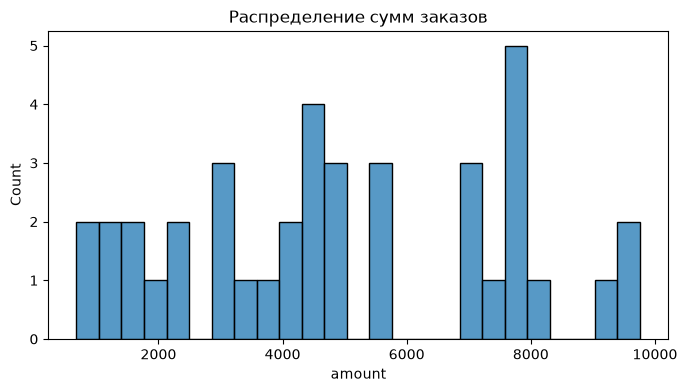

In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=df, x='amount', bins=25, ax=ax)
ax.set_title('Распределение сумм заказов')

Text(0.5, 1.0, 'Суммы заказов по городам')

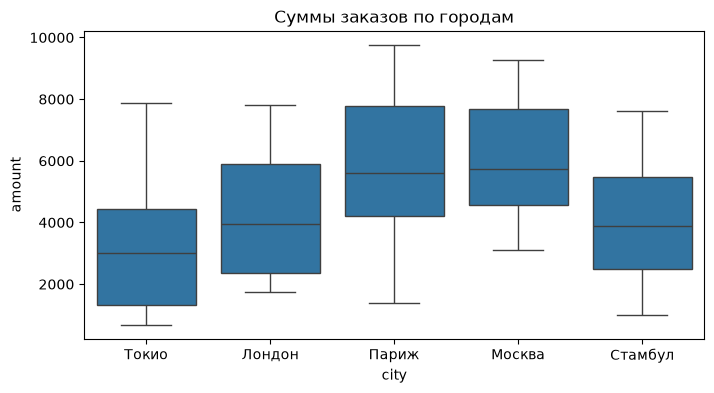

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df, x='city', y='amount', ax=ax)
ax.set_title('Суммы заказов по городам')

<Axes: xlabel='amount', ylabel='name'>

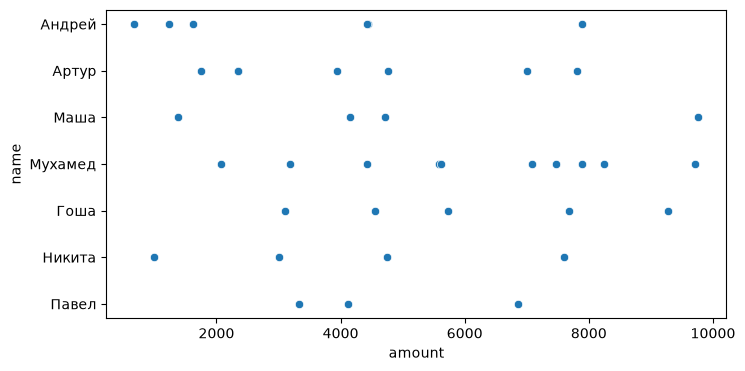

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.scatterplot(data=df, x='amount', y='name')

<Axes: xlabel='city', ylabel='amount'>

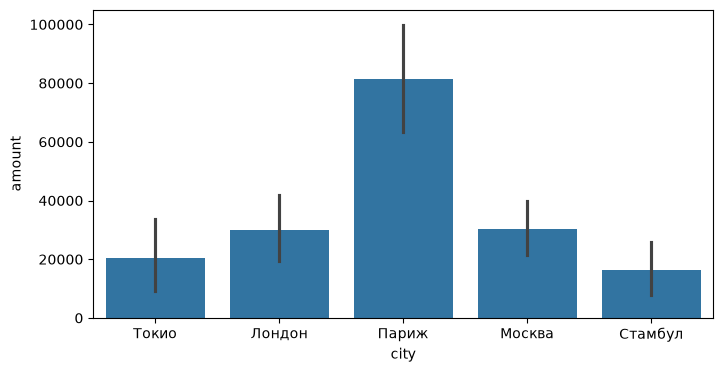

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=df, x='city', y='amount', estimator='sum')

In [6]:
df.groupby('city').amount.max()

city
Лондон     7805.996621
Москва     9274.973390
Париж      9758.661281
Стамбул    7605.068627
Токио      7890.551337
Name: amount, dtype: float64

<Axes: >

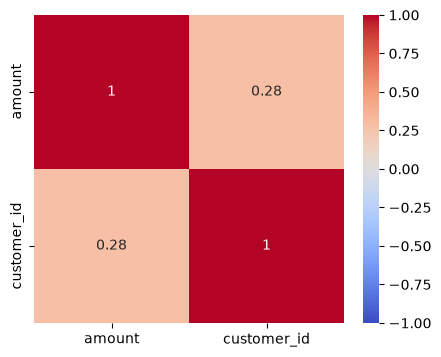

In [7]:
num = df[['amount', 'customer_id']]
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(num.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax)

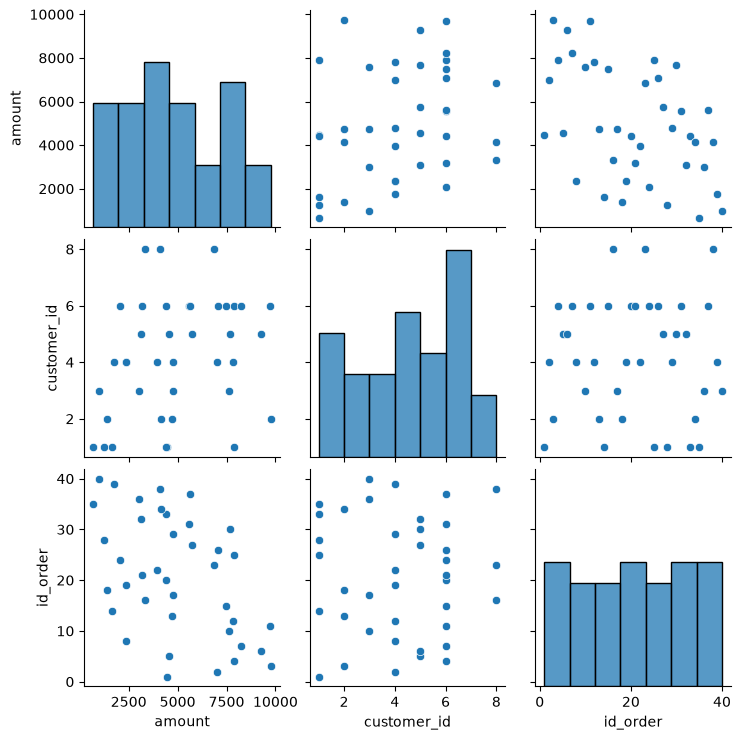

In [8]:
sns.pairplot(df[['amount', 'customer_id', 'id_order']])